In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE


In [2]:
file_path = "Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Data preparation
print(df.dtypes)



customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
# Removing Columns that will not be useful ex.: Gender;
df = df.drop("gender", axis=1)      
df = df.drop("customerID", axis=1)     
df = df.drop("tenure", axis=1)

display(df)

# Arranging the TotalCharges Column as Object;
# Treating errors as empty values "Coerce"
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce") 

# Eliminating Lines with Null values generated in "TotalCharges using DROPNA;
df = df.dropna(how = "any", axis = 0)

,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,0,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
# Count of Yes and No for Churns:
print("# churn:\n", df["Churn"].value_counts(), "\n")

# Show in Percentage using Normalize=True:
print("% of churn (%):\n",df["Churn"].value_counts(normalize=True).map("{:.2%}".format))

# churn:
 No     5163
Yes    1869
Name: Churn, dtype: int64 

% of churn (%):
 No     73.42%
Yes    26.58%
Name: Churn, dtype: object


In [7]:
# Converting the target variable "Churn" into binary numbers Yes=1 ; No = 0
df['Churn'] = np.where(df.Churn == 'Yes',1,0)

df.head()

,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [8]:
# Converting all categorical variables into dummy variables
df_dummies = pd.get_dummies(df)
df_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,29.85,29.85,0,0,1,1,0,1,0,...,0,1,0,0,0,1,0,0,1,0
1,0,56.95,1889.50,0,1,0,1,0,0,1,...,0,0,1,0,1,0,0,0,0,1
2,0,53.85,108.15,1,1,0,1,0,0,1,...,0,1,0,0,0,1,0,0,0,1
3,0,42.30,1840.75,0,1,0,1,0,1,0,...,0,0,1,0,1,0,1,0,0,0
4,0,70.70,151.65,1,1,0,1,0,0,1,...,0,1,0,0,0,1,0,0,1,0


(7032, 18)
       SeniorCitizen  MonthlyCharges  TotalCharges        Churn
count    7032.000000     7032.000000   7032.000000  7032.000000
mean        0.162400       64.798208   2283.300441     0.265785
std         0.368844       30.085974   2266.771362     0.441782
min         0.000000       18.250000     18.800000     0.000000
25%         0.000000       35.587500    401.450000     0.000000
50%         0.000000       70.350000   1397.475000     0.000000
75%         0.000000       89.862500   3794.737500     1.000000
max         1.000000      118.750000   8684.800000     1.000000
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges 

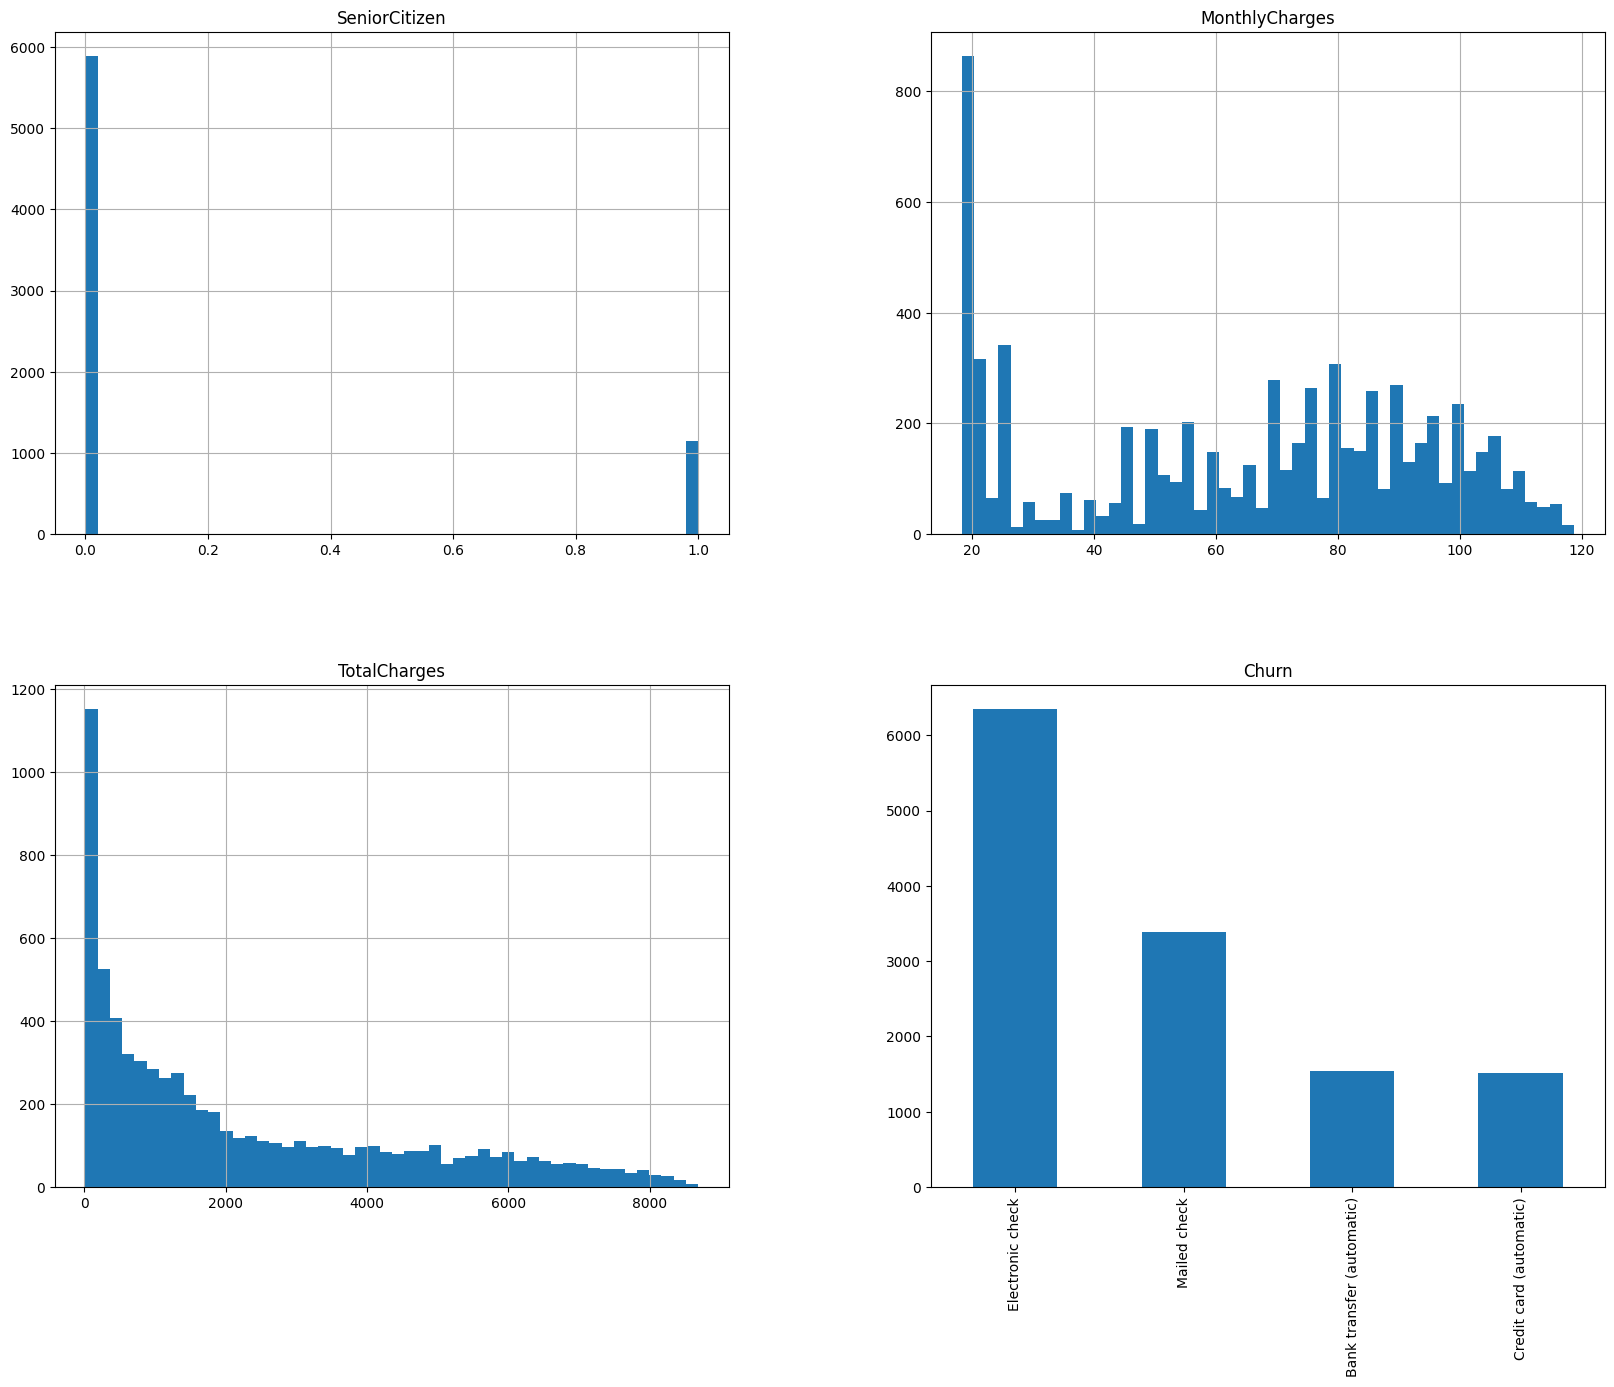

In [9]:
# some data exploration 

# Get the shape of the dataset
print(df.shape)

# Get the summary statistics of the dataset
print(df.describe())

# Get the count of unique values in each column
print(df.nunique())

# Get the count of missing values in each column
print(df.isnull().sum())

# Plot a histogram for each numeric column in the dataset
df.hist(bins=50, figsize=(20,15))

# Plot a bar plot for each categorical column in the dataset
for column in df.select_dtypes(include='object').columns:
    df[column].value_counts().plot(kind='bar')

In [10]:
# Split the data into features (X) and target variable (y)
X = df_dummies.drop("Churn", axis=1)
y = df_dummies["Churn"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# In this code, train_test_split function from the sklearn.model_selection library is used to split the data into 
# training and testing sets. The test_size argument is set to 0.2, which means 20% of the data will be used for testing 
# and 80% of the data will be used for training. 
#The random_state argument is set to 0, to set a seed for the random number generator, 
# ensuring that the same split is made every time the code is run.

In [11]:
X.head()



,SeniorCitizen,MonthlyCharges,TotalCharges,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,29.85,29.85,0,1,1,0,1,0,0,...,0,1,0,0,0,1,0,0,1,0
1,0,56.95,1889.50,1,0,1,0,0,1,1,...,0,0,1,0,1,0,0,0,0,1
2,0,53.85,108.15,1,0,1,0,0,1,1,...,0,1,0,0,0,1,0,0,0,1
3,0,42.30,1840.75,1,0,1,0,1,0,0,...,0,0,1,0,1,0,1,0,0,0
4,0,70.70,151.65,1,0,1,0,0,1,1,...,0,1,0,0,0,1,0,0,1,0


In [12]:
# Train the logistic regression model
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [13]:
# Predicting the data
y_pred=logistic_regression.predict(X_test)


In [24]:
#Metrics:
accuracy_lr = accuracy_score(y_test, y_pred, normalize=True)
f1_lr = f1_score(y_test, y_pred, average='binary')
roc_lr = roc_auc_score(y_test, y_pred, average='macro')
print(accuracy_lr)
print(f1_lr)
print(roc_lr)

0.8002842928216063
0.5748865355521937
0.7083196265488666
